##problem with llm
- think and understand anf text genrate but can not do work for u
- DuckDucckGo -can serch google for u


##tool binding
- whe conncet llm with tool


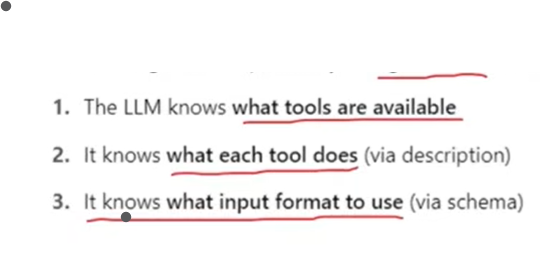

## with tool binding llm understnd
- what tool
- what input tool have
- how to invoke all tools

In [1]:
!pip install langchain langchain-core langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.6 MB/s eta 0:00:00


In [2]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key="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"
)

In [3]:
!pip install -q langchain-openai langchain-core requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.3/554.3 kB 13.2 MB/s eta 0:00:00


In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
import requests

In [5]:
@tool
def multiply(a: int, b: int) -> int:
  """Given 2 numbers a and b this tool returns their product"""
  return a * b

In [6]:
print(multiply.invoke({'a':3, 'b':4}))

12


###tool binding
- we need llm

In [7]:
llm.invoke('hi') #u have to store this into varibale

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.052267589, 'completion_tokens_details': None, 'prompt_time': 0.007182984, 'prompt_tokens_details': None, 'queue_time': 0.088550098, 'total_time': 0.059450573}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb617-43fe-7102-80d6-5f465466fc17-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [8]:
a = llm.bind_tools([multiply]) # wheneve the a need to mutiple
# a will check if a is having any tool --> hep to mitiple
# yess __> call tool(name)<> multiple


### not all llm is having ability to binde the tool only few llm can bind tool

## how and when the llm can call the tool

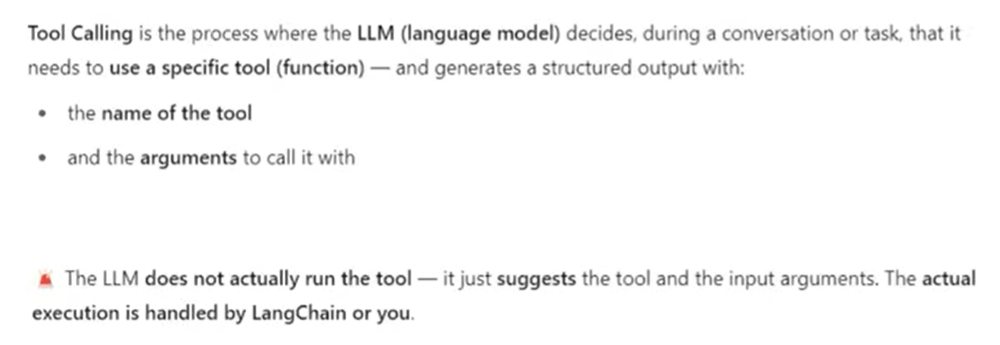

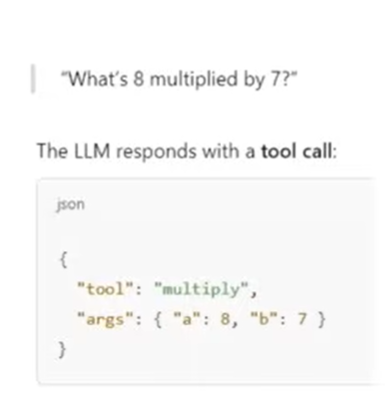

In [9]:
a.invoke('Hi')

AIMessage(content="I'm here to help. Is there something I can help you with, or would you like to use one of the available functions?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 231, 'total_tokens': 259, 'completion_time': 0.098507097, 'completion_tokens_details': None, 'prompt_time': 0.033108156, 'prompt_tokens_details': None, 'queue_time': 0.136006614, 'total_time': 0.131615253}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb617-4586-7621-8bba-c20b66841631-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 231, 'output_tokens': 28, 'total_tokens': 259})

In [10]:
a.invoke('what is 3 * 4')

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '582sn8f9g', 'function': {'arguments': '{"a":3,"b":4}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 237, 'total_tokens': 256, 'completion_time': 0.068595252, 'completion_tokens_details': None, 'prompt_time': 0.043996269, 'prompt_tokens_details': None, 'queue_time': 0.008432913, 'total_time': 0.112591521}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb617-46ec-7611-b363-c457bffa3bfc-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 4}, 'id': '582sn8f9g', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 237, 'output_tokens': 19, 'total_tokens': 256})

- as u can see content is emplty ''
- but u will notice
-tool_calls=
>[{'name': 'multiply', 'args': {'a': 3, 'b': 4}, 'id': 'anp4v4vg1', 'type': 'tool_call'}]  
- this in the output

##during tool calling
- it will print the name of tool
- it will also print what is schema (means what input do u need)

In [12]:
a.invoke('what is 3 * 4').tool_calls

[{'name': 'multiply',
  'args': {'a': 3, 'b': 4},
  'id': 'qvk6zyzp1',
  'type': 'tool_call'}]

here there can be more than one tool but but we only have one tool

In [16]:
a.invoke('what is 3 * 4').tool_calls[0] #llm think this tool can be heplfull to solve these

{'name': 'multiply',
 'args': {'a': 3, 'b': 4},
 'id': 'fk9m577er',
 'type': 'tool_call'}

- llm does not call the tool
- it only suggest tool
- tool call by langchain
## tool execution
- in these step llm will run python progam (the phython progam suggest by ll)
- run input suggested by llm


In [17]:
a.invoke('what is 3 * 4').tool_calls[0]['name']

'multiply'

In [18]:
a.invoke('what is 3 * 4').tool_calls[0]['args']

{'a': 3, 'b': 4}

In [23]:
multiply.invoke({'name': 'multiply',
 'args': {'a': 3, 'b': 4},
 'id': 'fk9m577er',
 'type': 'tool_call'})

ToolMessage(content='12', name='multiply', tool_call_id='fk9m577er')

## tool message
- it is message we get when we execute the tool


if u send these mutliply and send these
```
------------------------
{'name': 'multiply',
 'args': {'a': 3, 'b': 4},
 'id': 'fk9m577er',
 'type': 'tool_call'}
 -------------------------
 ```


In [22]:
multiply.invoke({'a': 3, 'b': 4})

12

if u want to see final answer
just send
args
```
----------------
{'a': 3, 'b': 4}
----------------
```

- now we have to send mdg to llm
- so llm will know what to answer


In [24]:
query='can u multiple 3 with 8'

In [ ]:
result=llm_with_tools.invoke('can u mutiple 3 with 8')

how to convert any query to humanMessgae

In [27]:
query=HumanMessage('can u multiple 3 with 8')

In [28]:
#with pu messga einto list
message=[query]

In [29]:
message

[HumanMessage(content='can u multiple 3 with 8', additional_kwargs={}, response_metadata={})]

In [40]:
result=a.invoke(message)

In [41]:
message.append(result)

In [42]:
message

[HumanMessage(content='can u multiple 3 with 8', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jye2pakat', 'function': {'arguments': '{"a":3,"b":10}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 239, 'total_tokens': 258, 'completion_time': 0.04927939, 'completion_tokens_details': None, 'prompt_time': 0.046834144, 'prompt_tokens_details': None, 'queue_time': 0.008368349, 'total_time': 0.096113534}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb64c-188d-75b1-bb8d-d5314f1b3240-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 10}, 'id': 'jye2pakat', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 239, 'output_tokens': 19, 'total_tokens': 258}),
 AIMessage(con

In [44]:
tool_result= multiply.invoke(message[1].tool_calls[0])

In [38]:
message

[HumanMessage(content='can u multiple 3 with 8', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jye2pakat', 'function': {'arguments': '{"a":3,"b":10}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 239, 'total_tokens': 258, 'completion_time': 0.04927939, 'completion_tokens_details': None, 'prompt_time': 0.046834144, 'prompt_tokens_details': None, 'queue_time': 0.008368349, 'total_time': 0.096113534}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb64c-188d-75b1-bb8d-d5314f1b3240-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3, 'b': 10}, 'id': 'jye2pakat', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 239, 'output_tokens': 19, 'total_tokens': 258})]

In [39]:
a.invoke(message)

AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 1, 'prompt_tokens': 256, 'total_tokens': 257, 'completion_time': 0.006673058, 'completion_tokens_details': None, 'prompt_time': 0.0139702, 'prompt_tokens_details': None, 'queue_time': None, 'total_time': 0.020643258}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb656-53e4-7410-926d-e01fb916d5cc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 256, 'output_tokens': 1, 'total_tokens': 257})

#currency conversion ai agent project
- we will hip api "exchange rate api"
- and tell the conversion factor

##tool
- one tool will hit pi and will tell the conversion fator  -- 85
- will convert the no. -- 8 * rupees

In [45]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
import requests

In [79]:
# tool create
from langchain_core.tools import InjectedToolArg
from typing import Annotated

@tool
def get_conversion_factor(base_currency: str,target:str) -> float:
  """
  This function fetches the currency conversion factor between a given base currency and a target currency
  """
  url = f'https://v6.exchangerate-api.com/v6/13b6907d40db4d97b6c96076/latest/{base_currency}'

  response = requests.get(url)

  data = response.json()

  conversion_rate = data['conversion_rates'][target]

  return conversion_rate

@tool
def convert(base_currency_value: int, conversion_rate: Annotated[float, InjectedToolArg]) -> float:
  """
  given a currency conversion rate this function calculates the target currency value from a given base currency value
  """

  return base_currency_value * conversion_rate

In [80]:
get_conversion_factor.invoke({'base_currency': 'USD','target':'INR'})

95.369

In [81]:
convert.invoke({'base_currency_value':10, 'conversion_rate':95.36})


953.6

In [64]:
!ip install langchain-groq

Object "install" is unknown, try "ip help".


In [65]:
from langchain_groq import ChatGroq

In [67]:
llm = model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key="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"
)

In [82]:
llm_with_tools = llm.bind_tools([get_conversion_factor, convert])

In [83]:
message=HumanMessage('what will in 10 USD in indian rupee  ')

In [84]:
message

HumanMessage(content='what will in 10 USD in indian rupee  ', additional_kwargs={}, response_metadata={})

In [85]:
ai_message=llm_with_tools.invoke([message])

In [86]:
ai_message

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'm293h2sgn', 'function': {'arguments': '{"base_currency":"USD","target":"INR"}', 'name': 'get_conversion_factor'}, 'type': 'function'}, {'id': '67dmx01wg', 'function': {'arguments': '{"base_currency_value":10}', 'name': 'convert'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 334, 'total_tokens': 371, 'completion_time': 0.100498098, 'completion_tokens_details': None, 'prompt_time': 0.036494201, 'prompt_tokens_details': None, 'queue_time': 0.008096754, 'total_time': 0.136992299}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb69e-0d03-79c2-872d-6b8b3cfcb1b8-0', tool_calls=[{'name': 'get_conversion_factor', 'args': {'base_currency': 'USD', 'target': 'INR'}, 'id': 'm293h2sgn', 'type': 'tool_call'}, {'name': 'convert', 'a

In [87]:
ai_messgae.tool_calls

[{'name': 'get_conversion_factor',
  'args': {'base_currency': 'USD', 'target': 'INR'},
  'id': '4thyxjdjy',
  'type': 'tool_call'},
 {'name': 'convert',
  'args': {'base_currency_value': 10},
  'id': '5cp1rd9s2',
  'type': 'tool_call'}]

In [77]:
ai_messgae.tool_calls[0]

{'name': 'get_conversion_factor',
 'args': {'base_currency': 'USD', 'target': 'INR'},
 'id': '4thyxjdjy',
 'type': 'tool_call'}

In [78]:
ai_messgae.tool_calls[1] #f u notice there when first function will
#provide the value of conversion  then only it iwll print in
#due to these we have power as programmer we can set this value

{'name': 'convert',
 'args': {'base_currency_value': 10},
 'id': '5cp1rd9s2',
 'type': 'tool_call'}

In [93]:
for tool_call in ai_messgae.tool_calls:
  print(tool_call)

{'name': 'get_conversion_factor', 'args': {'base_currency': 'USD', 'target': 'INR'}, 'id': '4thyxjdjy', 'type': 'tool_call'}
{'name': 'convert', 'args': {'base_currency_value': 10}, 'id': '5cp1rd9s2', 'type': 'tool_call'}


In [102]:
for tool_call in ai_messgae.tool_calls:
  print("tool_calls",tool_call)
  print("-"*10)
  #if tool call name get_conversion_factor execute that first
  #from which we will get the value of conversion rate
  if tool_call['name']=='get_conversion_factor':
    tool_message=get_conversion_factor.invoke(tool_call) #in invoke i have to pass the entire didctionary
    #mean first tool call
    print(tool_message)


tool_calls {'name': 'get_conversion_factor', 'args': {'base_currency': 'USD', 'target': 'INR'}, 'id': '4thyxjdjy', 'type': 'tool_call'}
----------
content='95.369' name='get_conversion_factor' tool_call_id='4thyxjdjy'
tool_calls {'name': 'convert', 'args': {'base_currency_value': 10}, 'id': '5cp1rd9s2', 'type': 'tool_call'}
----------


In [103]:
for tool_call in ai_messgae.tool_calls:

  #if tool call name get_conversion_factor execute that first
  #from which we will get the value of conversion rate
  if tool_call['name']=='get_conversion_factor':
    tool_message=get_conversion_factor.invoke(tool_call) #in invoke i have to pass the entire didctionary
    #mean first tool call
    print(tool_message)


content='95.369' name='get_conversion_factor' tool_call_id='4thyxjdjy'


In [104]:
#now i have to fetch this conversion rate
#then appent it to messgae lis
for tool_call in ai_messgae.tool_calls:
  if tool_call['name']=='get_conversion_factor':
    tool_message=get_conversion_factor.invoke(tool_call)
    print(tool_message.content)


95.369
